<a href="https://www.kaggle.com/code/omborse771924/fifa-world-cup-2026-player-eda-feature-engineering?scriptVersionId=327450464" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rauffauzanrambe/fifa-world-cup-2026-player-performance-dataset/fifa_world_cup_2026_player_performance.csv


## Loading Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/rauffauzanrambe/fifa-world-cup-2026-player-performance-dataset/fifa_world_cup_2026_player_performance.csv')

In [3]:
df.head()

,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left,...,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8
1,P00070,Ansu Le Normand,19,Spanish,Spain,18,Midfielder,178,75,Right,...,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5
2,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left,...,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4
3,P00073,Pedro Cubarsi,20,Spanish,Spain,21,Forward,182,74,Right,...,1.2,19.8,42.3,40.9,78.5,5,3,422,0,6.7
4,P00059,Alvaro Oyarzabal,23,Spanish,Spain,7,Defender,191,81,Left,...,6.2,44.1,33.5,60.0,56.6,0,0,440,0,5.7


In [4]:
df.tail()

,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
54595,P00996,Amir Younis,28,Iraqi,Iraq,8,Defender,177,73,Right,...,0.0,41.9,27.7,31.3,40.5,1,0,97,0,0.0
54596,P01006,Safaa Al-Khafaji,20,Iraqi,Iraq,18,Midfielder,176,72,Right,...,0.0,64.2,53.1,64.8,64.3,2,0,206,0,0.0
54597,P01008,Ahmed Hussein,26,Iraqi,Iraq,20,Midfielder,173,77,Left,...,0.0,75.4,55.0,65.0,64.5,1,1,359,0,0.0
54598,P00991,Ibrahim Mhawi,30,Iraqi,Iraq,3,Goalkeeper,190,81,Right,...,0.0,96.3,39.6,99.0,99.0,0,0,342,0,0.0
54599,P00989,Mohannad Hussein,27,Iraqi,Iraq,1,Goalkeeper,187,73,Right,...,0.0,99.0,34.1,99.0,99.0,0,0,286,0,0.0


In [5]:
df.describe()

,age,jersey_number,height_cm,weight_kg,market_value_eur,goals_team,goals_opponent,minutes_played,goals,assists,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
count,54600.000000,54600.000000,54600.000000,54600.000000,5.460000e+04,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,...,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000
mean,26.296484,13.500000,181.654341,75.754853,2.008445e+07,1.330476,1.330476,36.199817,0.055385,0.052363,...,2.850165,60.318379,46.135778,63.750396,55.572154,0.643993,0.607601,272.300311,0.030659,3.634046
std,4.067519,7.500069,6.277792,3.951481,2.718866e+07,1.147814,1.147814,36.419755,0.251900,0.239021,...,4.228436,20.234988,22.424337,19.860028,13.661343,1.093781,0.931527,116.806184,0.206520,3.163411
min,17.000000,1.000000,163.000000,65.000000,5.288220e+05,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,15.000000,5.000000,25.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,7.000000,177.000000,73.000000,4.444778e+06,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,43.700000,29.800000,46.500000,46.400000,0.000000,0.000000,184.000000,0.000000,0.000000
50%,26.000000,13.500000,182.000000,76.000000,1.027111e+07,1.000000,1.000000,24.000000,0.000000,0.000000,...,1.100000,57.000000,40.500000,61.100000,55.000000,0.000000,0.000000,268.000000,0.000000,5.400000
75%,29.000000,20.000000,186.000000,78.000000,2.342013e+07,2.000000,2.000000,75.000000,0.000000,0.000000,...,4.000000,75.100000,59.000000,78.900000,63.900000,1.000000,1.000000,359.000000,0.000000,6.400000
max,39.000000,26.000000,200.000000,87.000000,2.000000e+08,7.000000,7.000000,90.000000,4.000000,3.000000,...,37.000000,99.000000,99.000000,99.000000,99.000000,10.000000,8.000000,615.000000,4.000000,9.500000


In [6]:
df.isnull()

,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54595,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
54596,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
54597,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
54598,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [7]:
df.isnull().sum()

player_id                   0
player_name                 0
age                         0
nationality                 0
team                        0
                           ..
total_goals_tournament      0
total_assists_tournament    0
total_minutes_tournament    0
player_of_match_awards      0
tournament_rating           0
Length: 75, dtype: int64

In [8]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
54595    False
54596    False
54597    False
54598    False
54599    False
Length: 54600, dtype: bool

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.columns

Index(['player_id', 'player_name', 'age', 'nationality', 'team',
       'jersey_number', 'position', 'height_cm', 'weight_kg', 'preferred_foot',
       'club_name', 'market_value_eur', 'match_id', 'match_date', 'stadium',
       'city', 'opponent_team', 'tournament_stage', 'match_result',
       'goals_team', 'goals_opponent', 'minutes_played', 'goals', 'assists',
       'shots', 'shots_on_target', 'expected_goals_xg', 'expected_assists_xa',
       'key_passes', 'successful_passes', 'total_passes', 'pass_accuracy',
       'dribbles_attempted', 'successful_dribbles', 'crosses',
       'successful_crosses', 'tackles', 'interceptions', 'clearances',
       'blocks', 'aerial_duels_won', 'aerial_duels_lost', 'recoveries',
       'defensive_actions', 'fouls_committed', 'fouls_suffered',
       'yellow_cards', 'red_cards', 'offsides', 'saves', 'save_percentage',
       'punches', 'clean_sheet', 'goals_conceded', 'penalty_saves',
       'distance_covered_km', 'sprint_distance_km', 'top_speed_k

## EDA

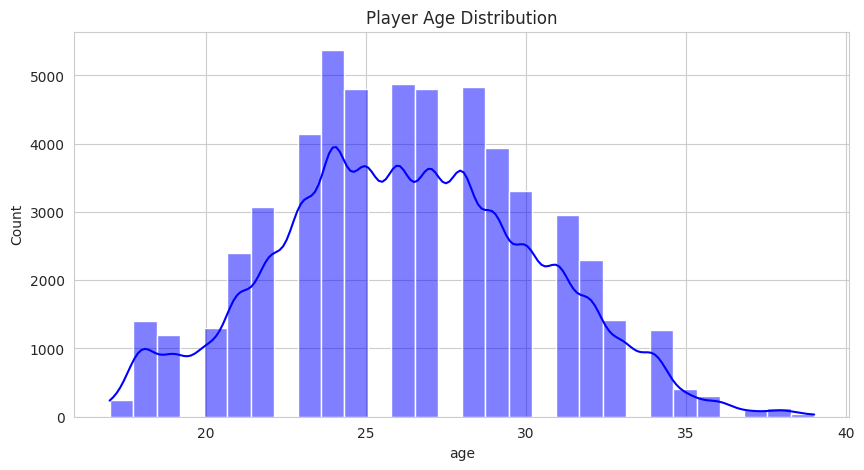

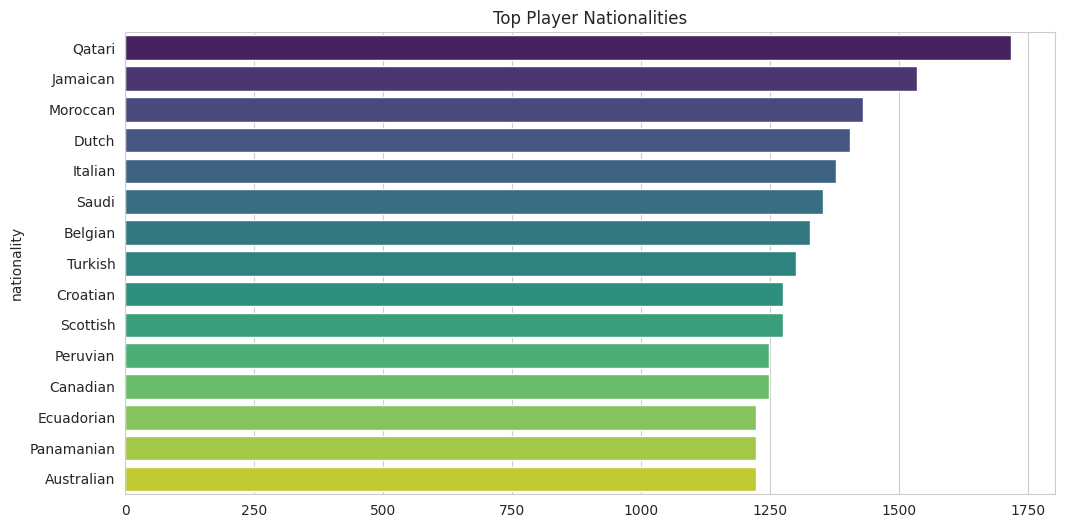

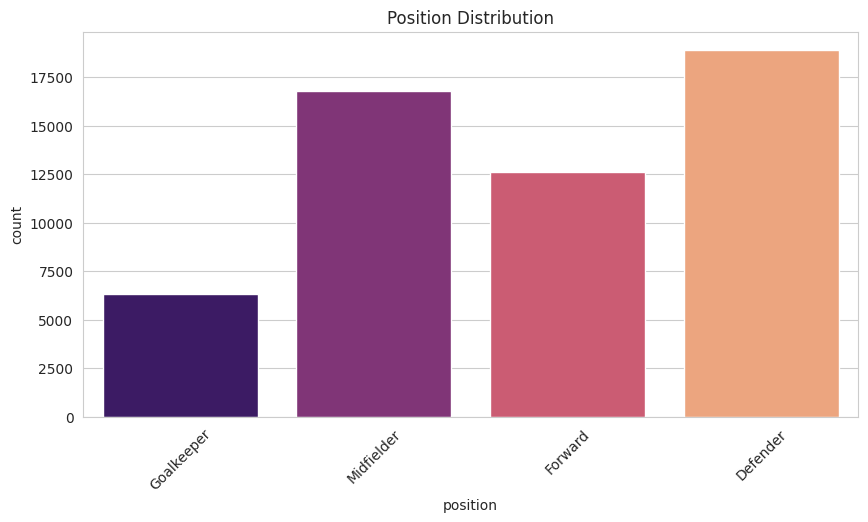

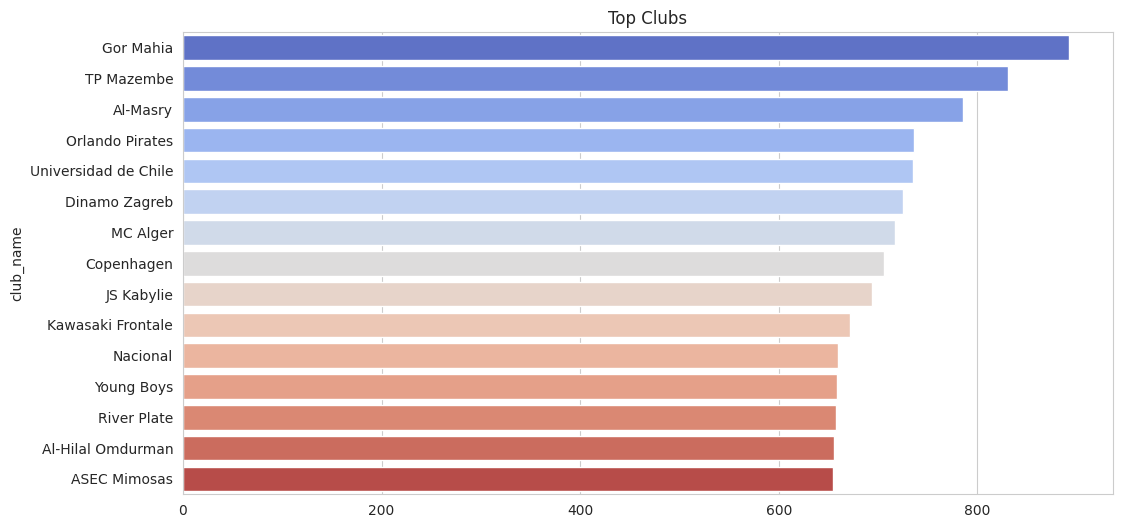

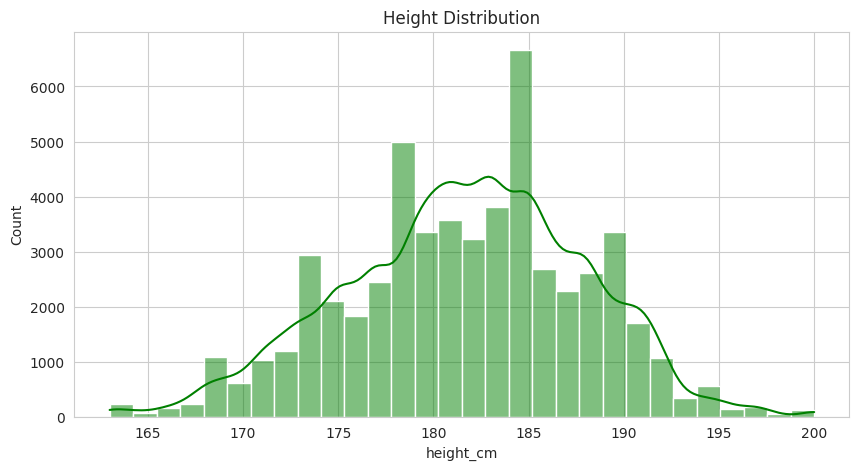

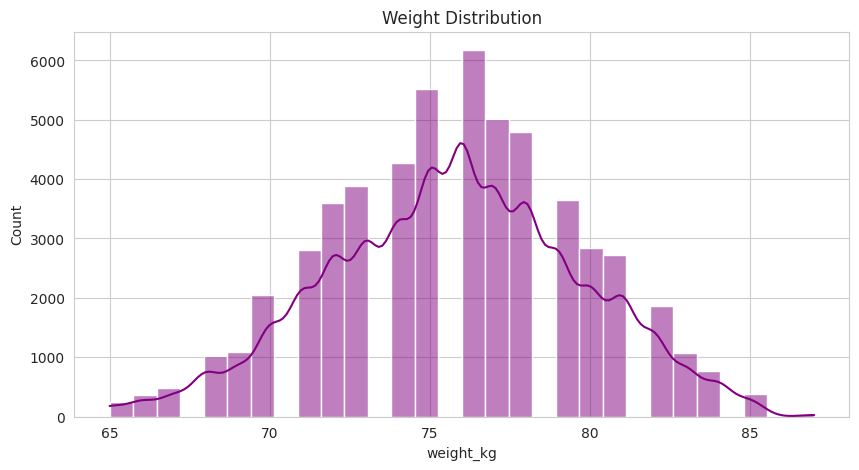

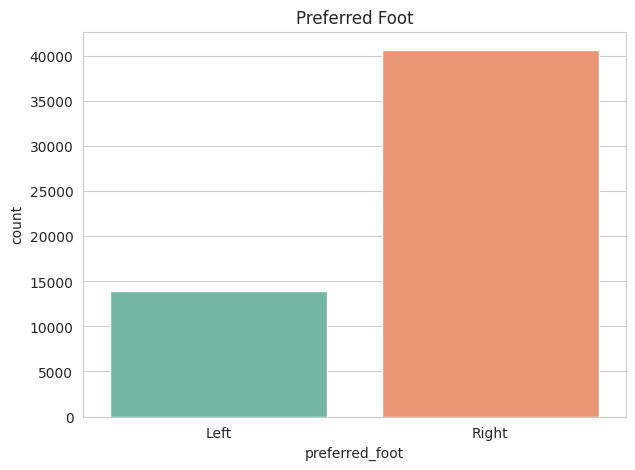

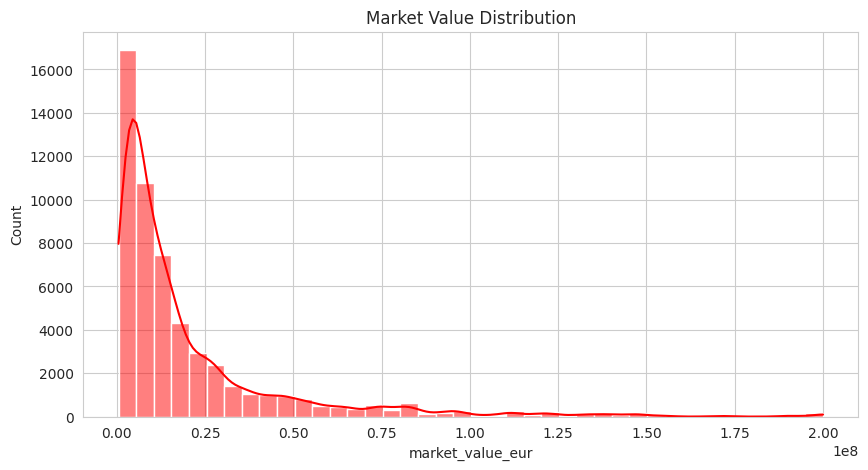

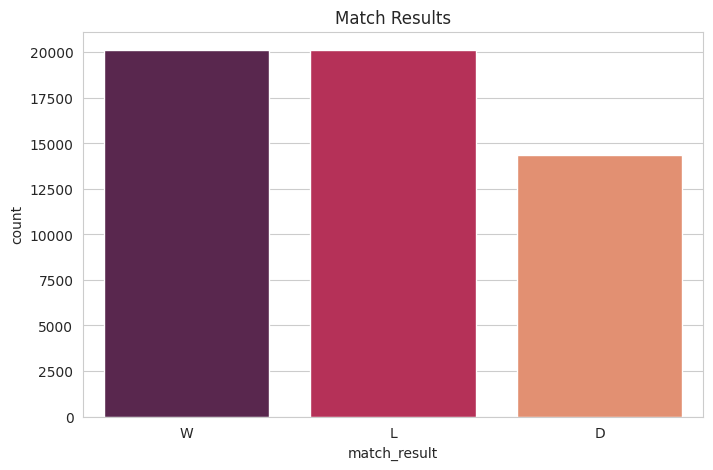

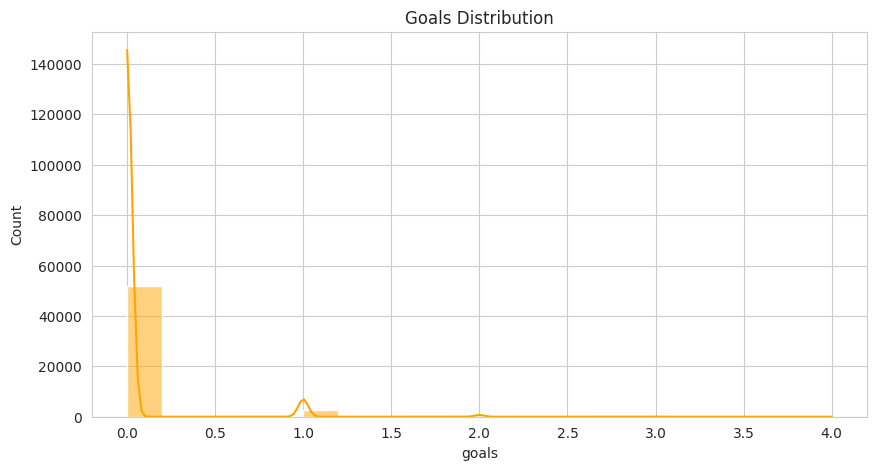

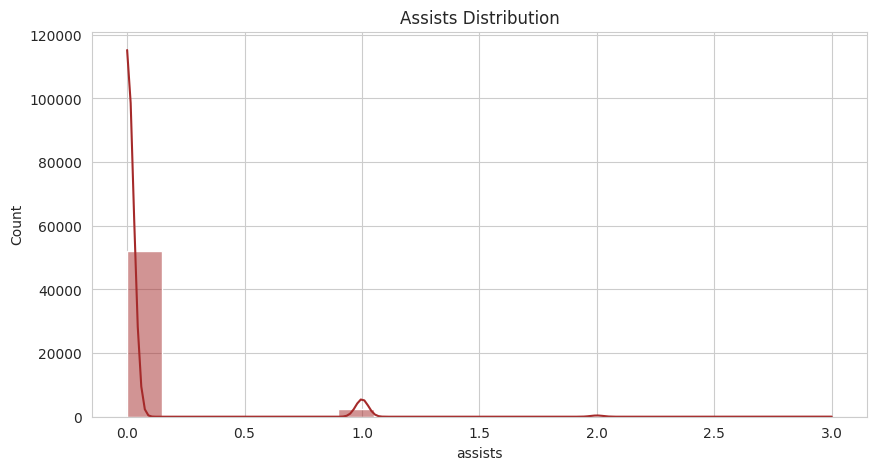

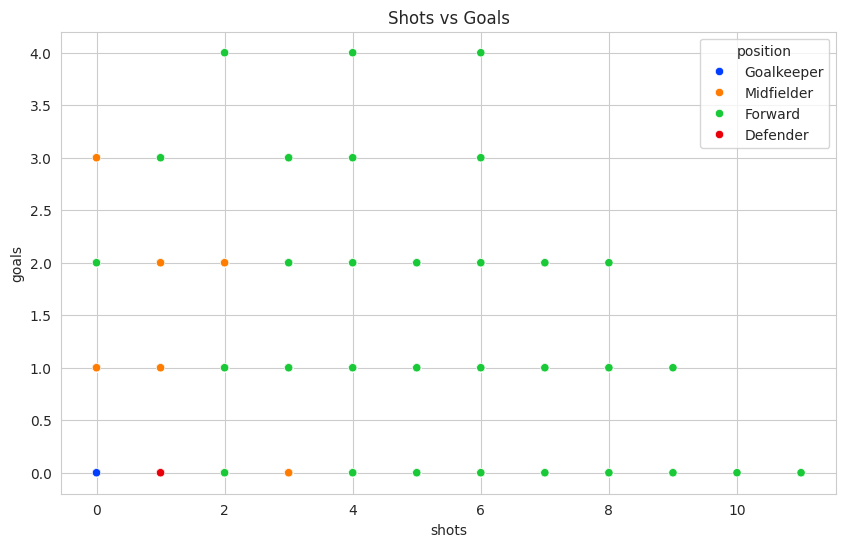

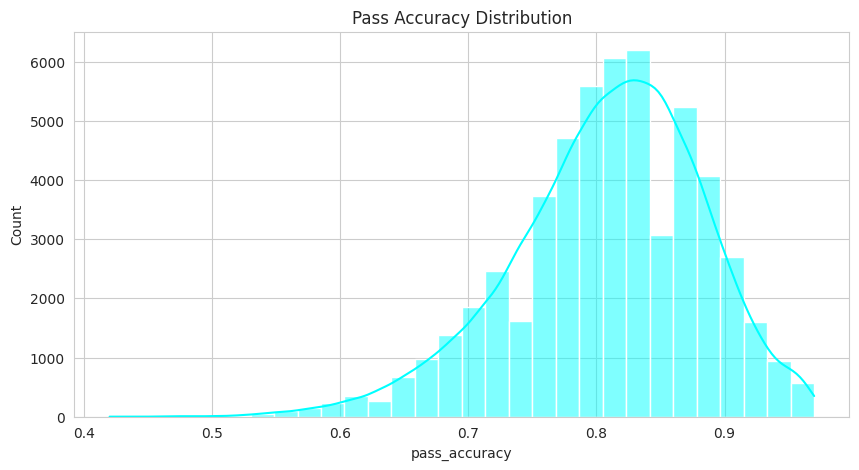

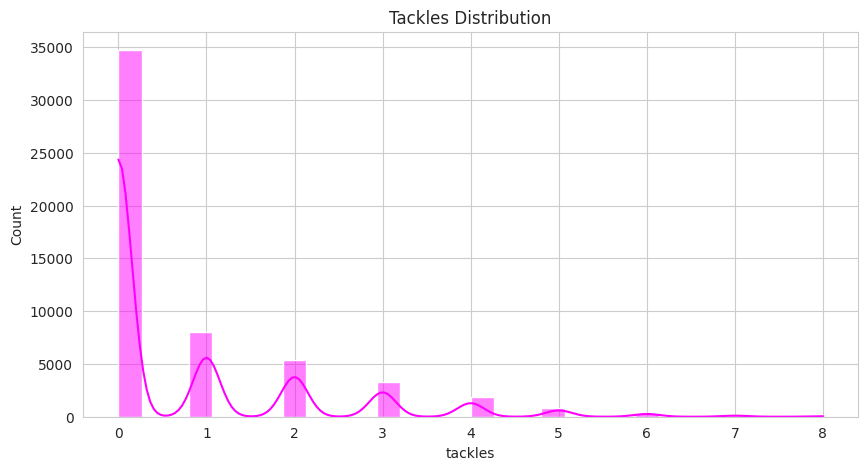

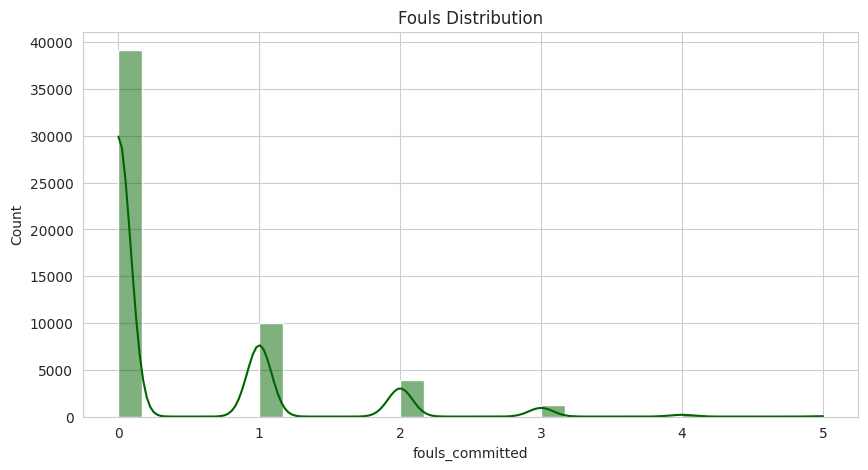

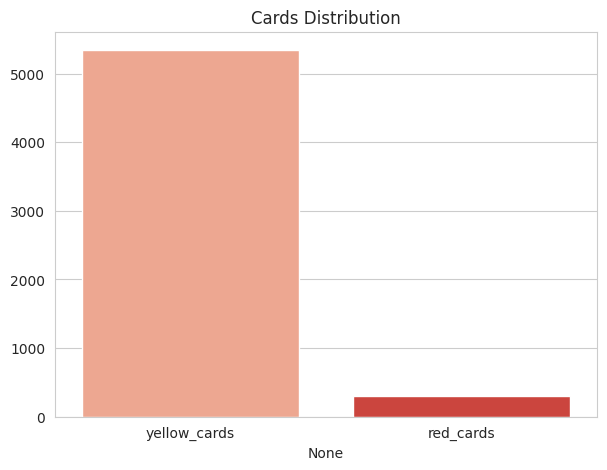

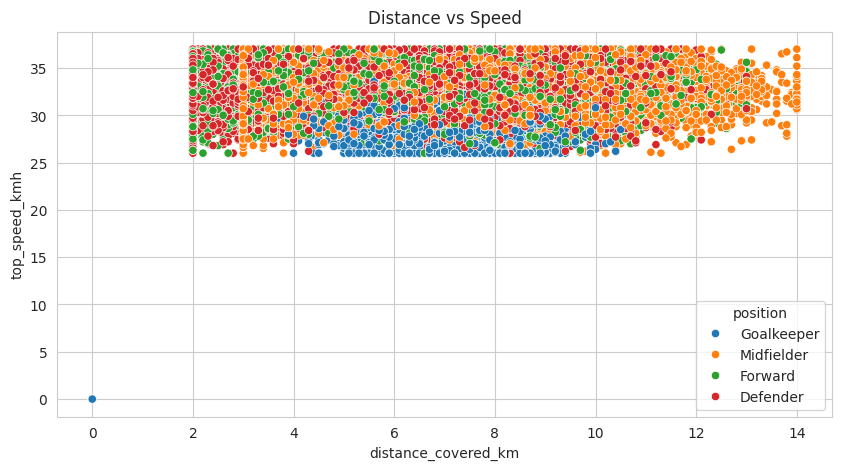

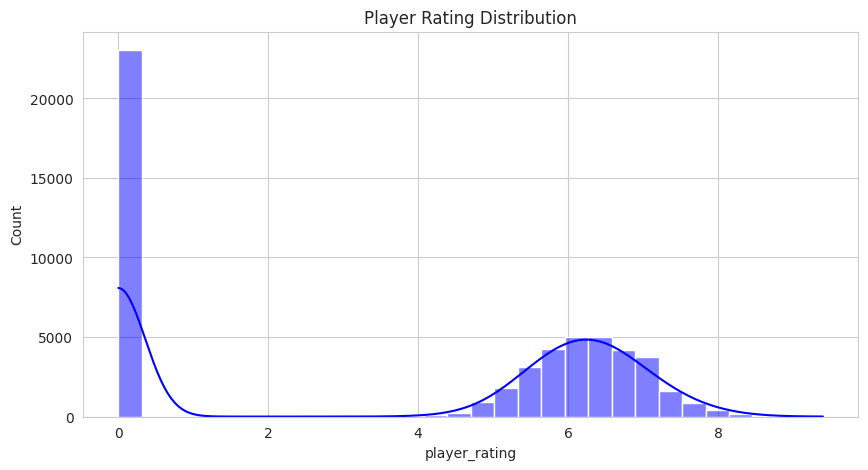

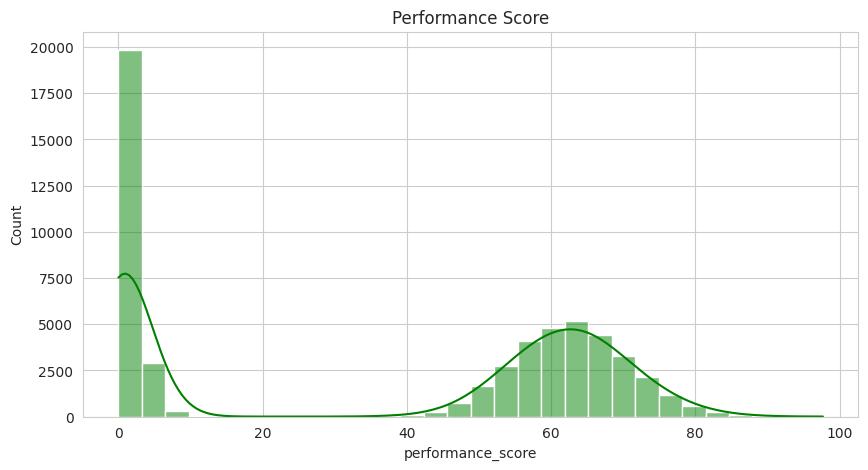

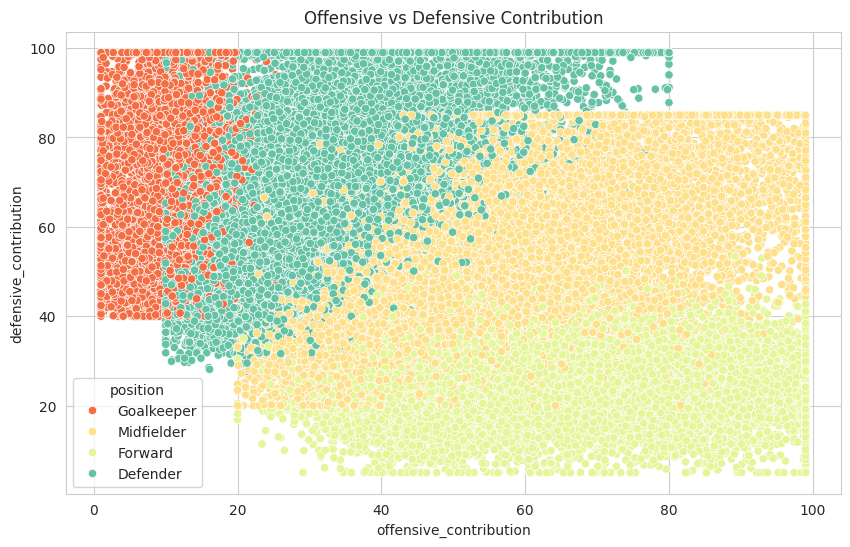

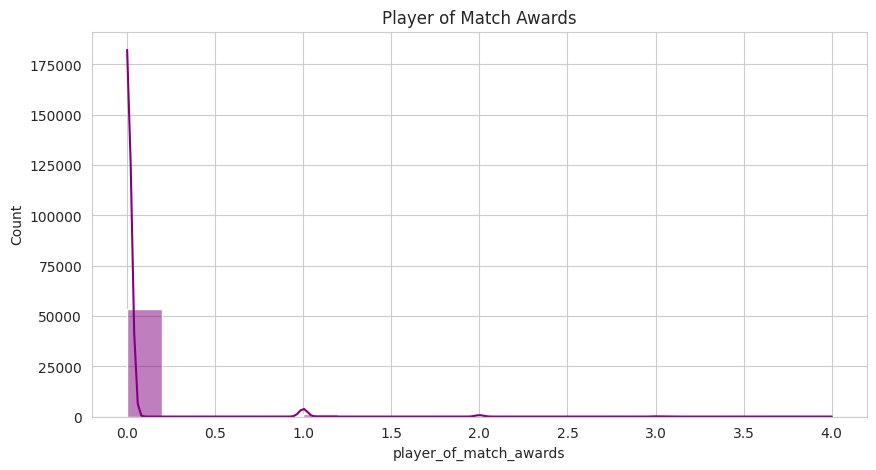

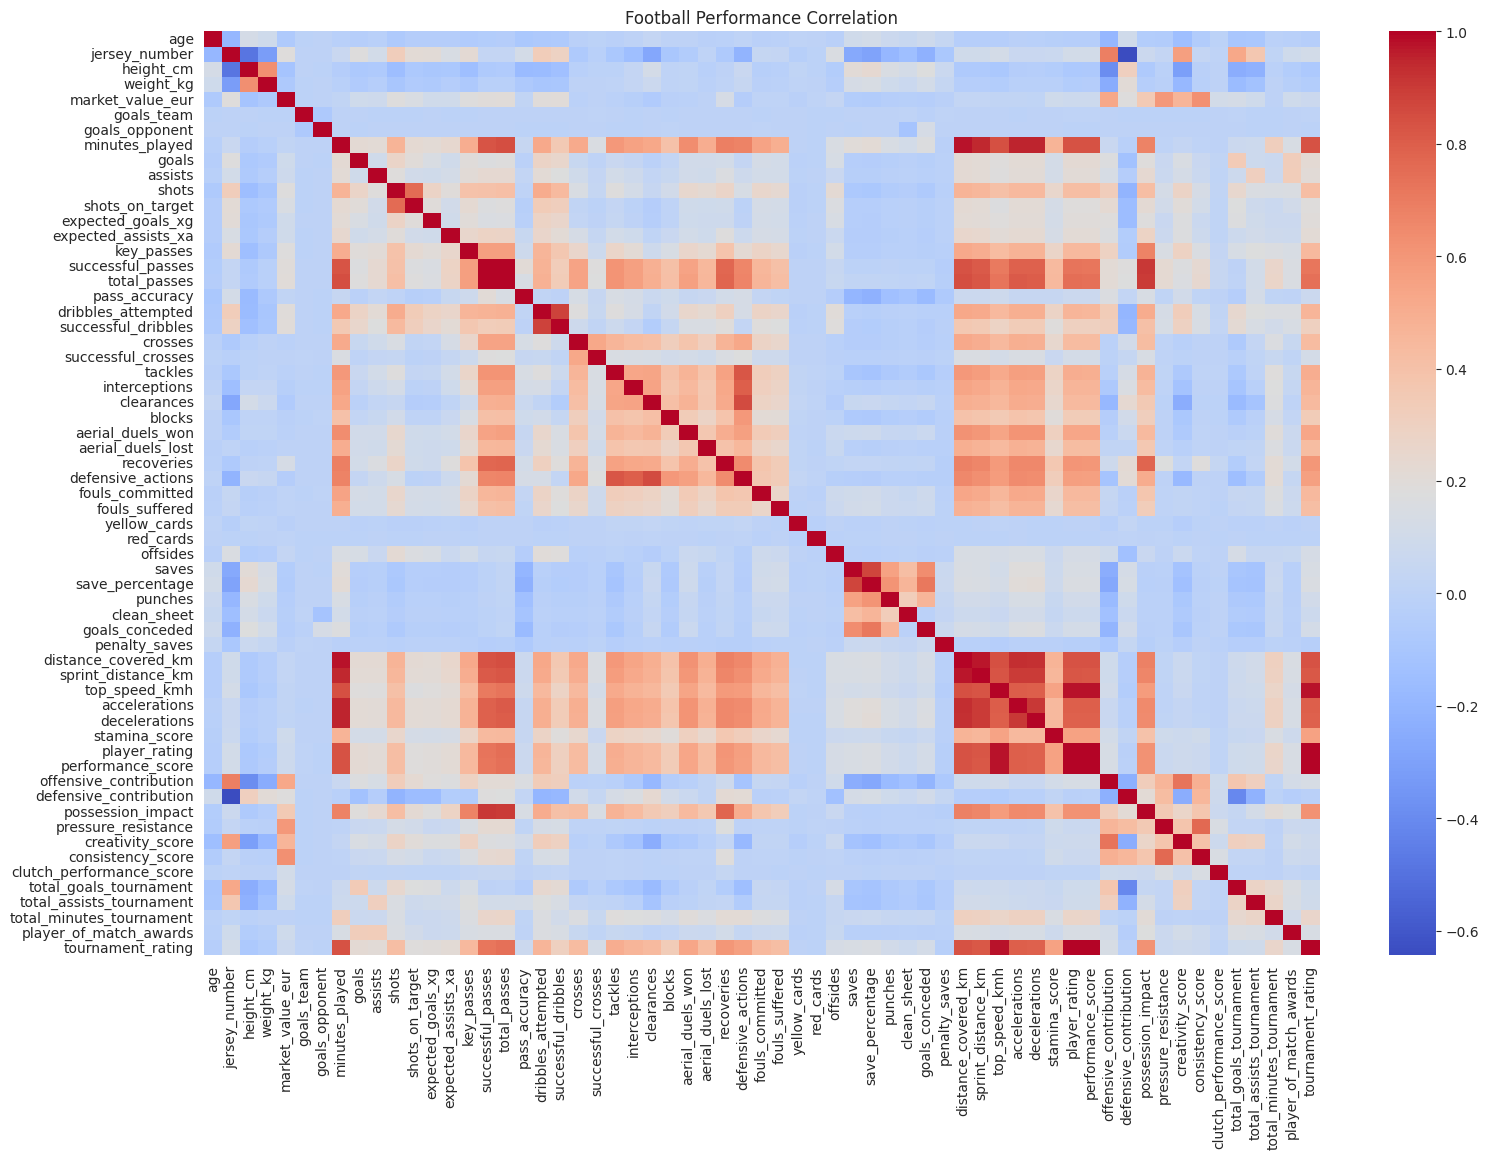

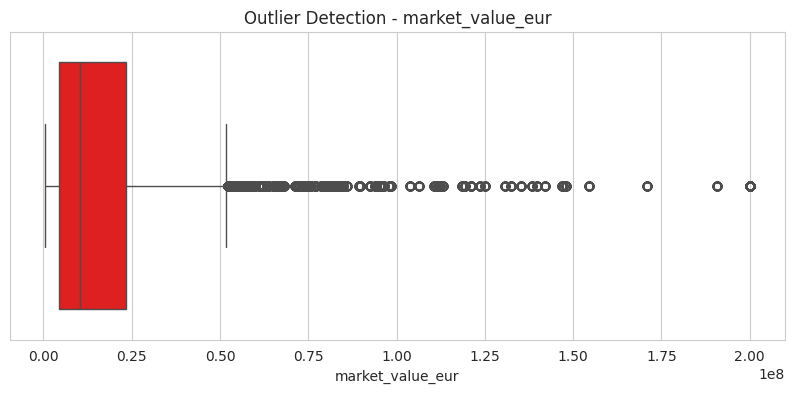

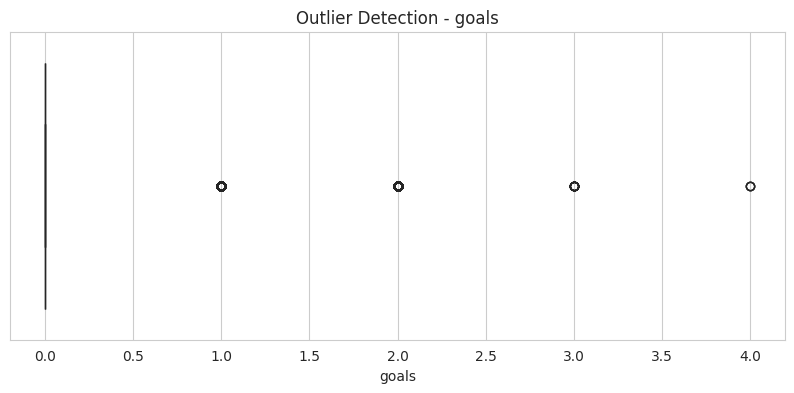

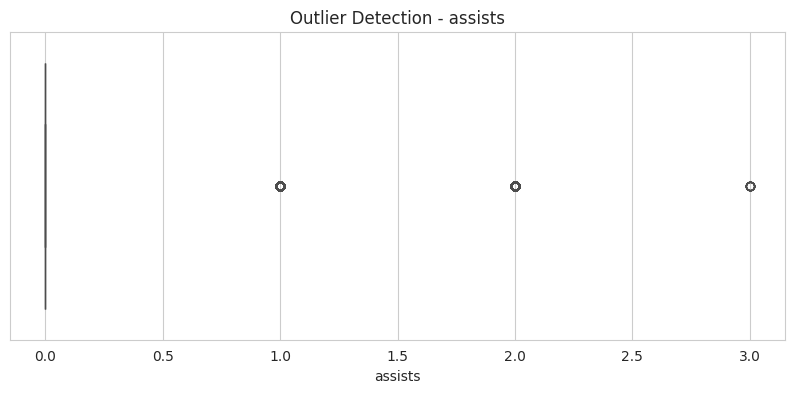

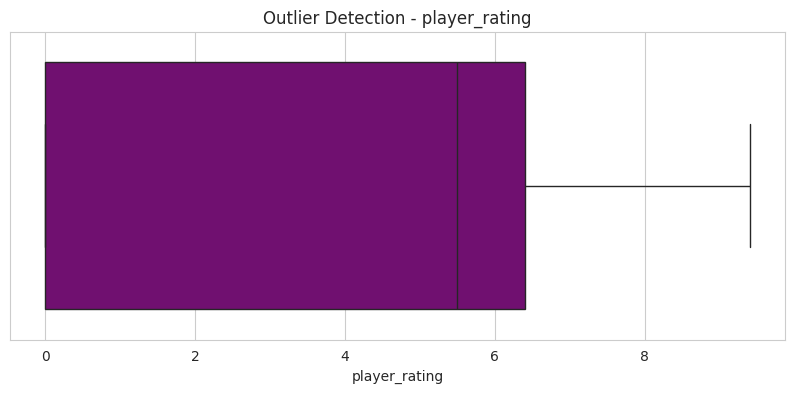

Football Player Visualization Completed Successfully


In [11]:
sns.set_style("whitegrid")
# ============================================================
# 1. AGE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10,5))

sns.histplot(
    df["age"],
    bins=30,
    kde=True,
    color="blue"
)

plt.title(
    "Player Age Distribution"
)

plt.show()








# ============================================================
# 2. TOP NATIONALITIES
# ============================================================

nationality=df["nationality"].value_counts().head(15)


plt.figure(figsize=(12,6))


sns.barplot(
    x=nationality.values,
    y=nationality.index,
    hue=nationality.index,
    palette="viridis",
    legend=False
)


plt.title(
    "Top Player Nationalities"
)


plt.show()









# ============================================================
# 3. PLAYER POSITIONS
# ============================================================


plt.figure(figsize=(10,5))


sns.countplot(

    data=df,

    x="position",

    hue="position",

    palette="magma",

    legend=False

)



plt.title(
    "Position Distribution"
)


plt.xticks(rotation=45)


plt.show()








# ============================================================
# 4. CLUB ANALYSIS
# ============================================================

clubs=df["club_name"].value_counts().head(15)



plt.figure(figsize=(12,6))


sns.barplot(

    x=clubs.values,

    y=clubs.index,

    hue=clubs.index,

    palette="coolwarm",

    legend=False

)



plt.title(
    "Top Clubs"
)



plt.show()








# ============================================================
# 5. HEIGHT DISTRIBUTION
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

    df["height_cm"],

    kde=True,

    bins=30,

    color="green"

)



plt.title(
    "Height Distribution"
)


plt.show()








# ============================================================
# 6. WEIGHT DISTRIBUTION
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

    df["weight_kg"],

    kde=True,

    bins=30,

    color="purple"

)



plt.title(
    "Weight Distribution"
)


plt.show()








# ============================================================
# 7. PREFERRED FOOT
# ============================================================


plt.figure(figsize=(7,5))


sns.countplot(

    data=df,

    x="preferred_foot",

    hue="preferred_foot",

    palette="Set2",

    legend=False

)



plt.title(
    "Preferred Foot"
)


plt.show()









# ============================================================
# 8. MARKET VALUE
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

    df["market_value_eur"],

    bins=40,

    kde=True,

    color="red"

)



plt.title(
    "Market Value Distribution"
)


plt.show()








# ============================================================
# 9. MATCH RESULTS
# ============================================================


plt.figure(figsize=(8,5))


sns.countplot(

data=df,

x="match_result",

hue="match_result",

palette="rocket",

legend=False

)


plt.title(
"Match Results"
)


plt.show()









# ============================================================
# 10. GOALS DISTRIBUTION
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

df["goals"],

bins=20,

kde=True,

color="orange"

)



plt.title(
"Goals Distribution"
)


plt.show()








# ============================================================
# 11. ASSISTS DISTRIBUTION
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

df["assists"],

bins=20,

kde=True,

color="brown"

)



plt.title(
"Assists Distribution"
)


plt.show()







# ============================================================
# 12. SHOTS VS GOALS
# ============================================================


plt.figure(figsize=(10,6))


sns.scatterplot(

data=df,

x="shots",

y="goals",

hue="position",

palette="bright"

)



plt.title(
"Shots vs Goals"
)


plt.show()








# ============================================================
# 13. PASS ACCURACY
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

df["pass_accuracy"],

bins=30,

kde=True,

color="cyan"

)


plt.title(
"Pass Accuracy Distribution"
)


plt.show()








# ============================================================
# 14. TACKLES ANALYSIS
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

df["tackles"],

bins=30,

kde=True,

color="magenta"

)



plt.title(
"Tackles Distribution"
)


plt.show()








# ============================================================
# 15. FOULS COMMITTED
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

df["fouls_committed"],

bins=30,

kde=True,

color="darkgreen"

)



plt.title(
"Fouls Distribution"
)


plt.show()








# ============================================================
# 16. CARD ANALYSIS
# ============================================================


cards = df[
[
"yellow_cards",
"red_cards"
]
].sum()



plt.figure(figsize=(7,5))


sns.barplot(

x=cards.index,

y=cards.values,

hue=cards.index,

palette="Reds",

legend=False

)


plt.title(
"Cards Distribution"
)


plt.show()









# ============================================================
# 17. FITNESS METRICS
# ============================================================


plt.figure(figsize=(10,5))


sns.scatterplot(

data=df,

x="distance_covered_km",

y="top_speed_kmh",

hue="position",

palette="tab10"

)


plt.title(
"Distance vs Speed"
)


plt.show()







# ============================================================
# 18. PLAYER RATING
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

df["player_rating"],

bins=30,

kde=True,

color="blue"

)


plt.title(
"Player Rating Distribution"
)


plt.show()








# ============================================================
# 19. PERFORMANCE SCORE
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

df["performance_score"],

bins=30,

kde=True,

color="green"

)


plt.title(
"Performance Score"
)


plt.show()







# ============================================================
# 20. OFFENSIVE VS DEFENSIVE
# ============================================================


plt.figure(figsize=(10,6))


sns.scatterplot(

data=df,

x="offensive_contribution",

y="defensive_contribution",

hue="position",

palette="Spectral"

)


plt.title(
"Offensive vs Defensive Contribution"
)


plt.show()








# ============================================================
# 21. PLAYER OF MATCH AWARDS
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

df["player_of_match_awards"],

bins=20,

kde=True,

color="purple"

)


plt.title(
"Player of Match Awards"
)


plt.show()









# ============================================================
# 22. CORRELATION HEATMAP
# ============================================================


numeric=df.select_dtypes(
include=np.number
)


plt.figure(figsize=(18,12))


sns.heatmap(

numeric.corr(),

cmap="coolwarm"

)


plt.title(
"Football Performance Correlation"
)


plt.show()









# ============================================================
# 23. OUTLIER DETECTION
# ============================================================


features=[

"market_value_eur",

"goals",

"assists",

"player_rating"

]



colors=[

"red",

"green",

"blue",

"purple"

]



for feature,color in zip(features,colors):


    plt.figure(figsize=(10,4))


    sns.boxplot(

        x=df[feature],

        color=color

    )


    plt.title(
        f"Outlier Detection - {feature}"
    )


    plt.show()





print(
    "Football Player Visualization Completed Successfully"
)

## Features Engineering

performance_level
Low       18349
Medium    18128
High      18123
Name: count, dtype: int64

Logistic Regression
Accuracy: 0.7096
              precision    recall  f1-score   support

        High       0.69      0.71      0.70      3625
         Low       0.79      1.00      0.88      3670
      Medium       0.59      0.42      0.49      3625

    accuracy                           0.71     10920
   macro avg       0.69      0.71      0.69     10920
weighted avg       0.69      0.71      0.69     10920


Decision Tree
Accuracy: 0.6189
              precision    recall  f1-score   support

        High       0.63      0.63      0.63      3625
         Low       0.80      0.80      0.80      3670
      Medium       0.43      0.42      0.42      3625

    accuracy                           0.62     10920
   macro avg       0.62      0.62      0.62     10920
weighted avg       0.62      0.62      0.62     10920


Random Forest
Accuracy: 0.7147
              precision    recall  f1-score 

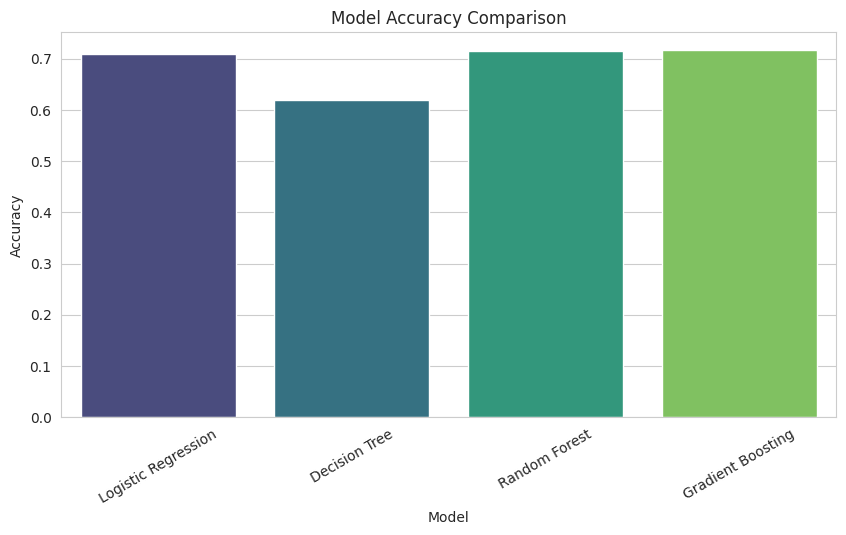

BEST MODEL: Gradient Boosting


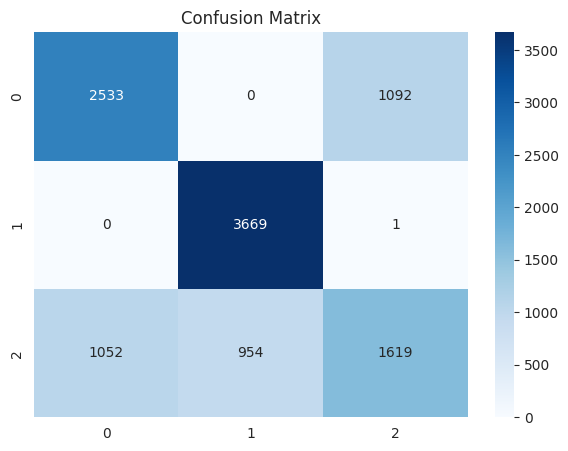

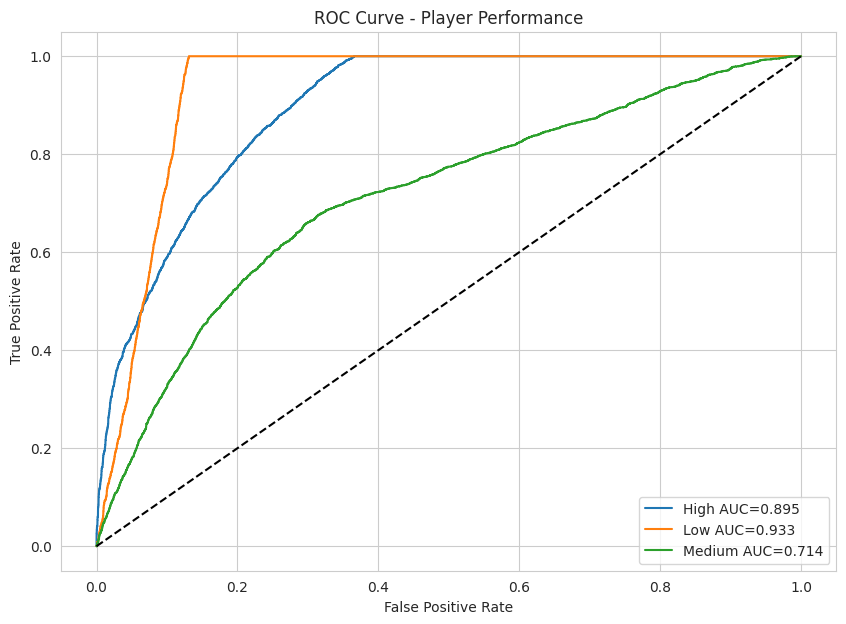

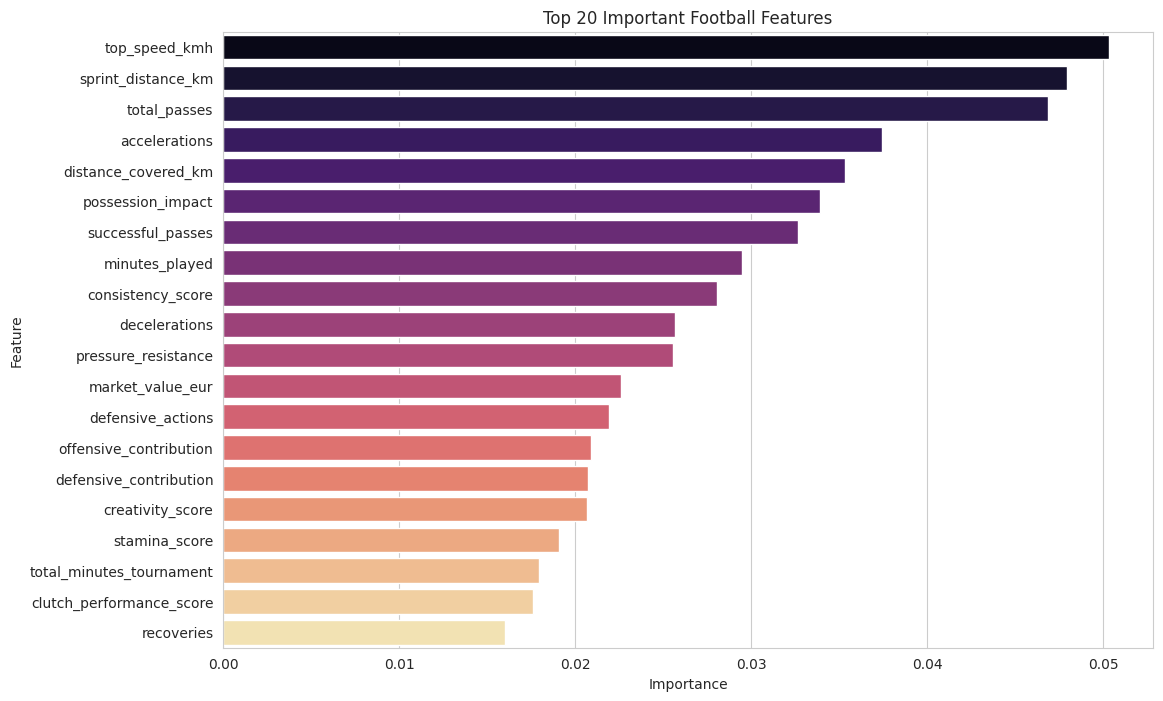


FINAL RESULT
Logistic Regression : 0.7096
Decision Tree : 0.6189
Random Forest : 0.7147
Gradient Boosting : 0.7162
BEST MODEL: Gradient Boosting
BEST ACCURACY: 0.7162


In [12]:
from sklearn.model_selection import train_test_split


from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    label_binarize
)


from sklearn.compose import ColumnTransformer


from sklearn.pipeline import Pipeline


from sklearn.impute import SimpleImputer


from sklearn.linear_model import LogisticRegression


from sklearn.tree import DecisionTreeClassifier


from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)


from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)
# ============================================================
# CREATE TARGET
# ============================================================


df["performance_level"] = pd.qcut(

    df["performance_score"],

    q=3,

    labels=[

        "Low",

        "Medium",

        "High"

    ]

)





print(

df["performance_level"]
.value_counts()

)










# ============================================================
# REMOVE DATA LEAKAGE
# ============================================================


drop_cols=[


# target

"performance_level",



# used for creating target

"performance_score",



# related direct score leakage

"player_rating",

"tournament_rating",



# identifiers

"player_id",

"player_name",

"match_id",



# date

"match_date"


]






X=df.drop(

    columns=drop_cols

)



y=df[

"performance_level"

]









# ============================================================
# TRAIN TEST SPLIT BEFORE ENCODING
# ============================================================


X_train,X_test,y_train,y_test=train_test_split(

    X,

    y,


    test_size=0.2,


    random_state=42,


    stratify=y

)









# ============================================================
# COLUMN TYPES
# ============================================================


numeric_cols=X.select_dtypes(

include=np.number

).columns




categorical_cols=X.select_dtypes(

include="object"

).columns










# ============================================================
# NUMERIC PIPELINE
# ============================================================


numeric_pipeline=Pipeline(

steps=[


(

"imputer",

SimpleImputer(
strategy="median"
)

),



(

"scaler",

StandardScaler()

)


]

)











# ============================================================
# CATEGORICAL PIPELINE
# ============================================================


categorical_pipeline=Pipeline(

steps=[



(

"imputer",

SimpleImputer(
strategy="most_frequent"
)

),




(

"encoder",

OneHotEncoder(
handle_unknown="ignore"
)

)



]

)










# ============================================================
# PREPROCESSOR
# ============================================================


preprocessor=ColumnTransformer(

transformers=[



(

"num",

numeric_pipeline,

numeric_cols

),




(

"cat",

categorical_pipeline,

categorical_cols

)


]

)










# ============================================================
# MODELS
# ============================================================


models={



"Logistic Regression":

LogisticRegression(
max_iter=1000
),





"Decision Tree":

DecisionTreeClassifier(
random_state=42
),





"Random Forest":

RandomForestClassifier(

n_estimators=200,

random_state=42

),





"Gradient Boosting":

GradientBoostingClassifier(

random_state=42

)


}










results={}

trained_models={}









# ============================================================
# TRAIN MODELS
# ============================================================


for name,model in models.items():


    print("\n===================")

    print(name)

    print("===================")





    pipe=Pipeline(

    steps=[




    (

    "preprocessor",

    preprocessor

    ),





    (

    "model",

    model

    )



    ]

    )








    pipe.fit(

    X_train,

    y_train

    )







    prediction=pipe.predict(

    X_test

    )








    acc=accuracy_score(

    y_test,

    prediction

    )







    results[name]=acc


    trained_models[name]=pipe







    print(

    "Accuracy:",

    round(acc,4)

    )






    print(

    classification_report(

    y_test,

    prediction

    )

    )










# ============================================================
# ACCURACY COMPARISON
# ============================================================


accuracy_df=pd.DataFrame({

"Model":list(results.keys()),

"Accuracy":list(results.values())

})







plt.figure(figsize=(10,5))


sns.barplot(

data=accuracy_df,

x="Model",

y="Accuracy",

hue="Model",

palette="viridis",

legend=False

)



plt.title(

"Model Accuracy Comparison"

)



plt.xticks(rotation=30)


plt.show()











# ============================================================
# BEST MODEL
# ============================================================


best_name=max(

results,

key=results.get

)




best_model=trained_models[

best_name

]






print(

"BEST MODEL:",

best_name

)










# ============================================================
# CONFUSION MATRIX
# ============================================================


best_pred=best_model.predict(

X_test

)





plt.figure(figsize=(7,5))



sns.heatmap(

confusion_matrix(

y_test,

best_pred

),

annot=True,

fmt="d",

cmap="Blues"

)





plt.title(

"Confusion Matrix"

)



plt.show()










# ============================================================
# MULTICLASS ROC CURVE
# ============================================================


classes=np.unique(y)




y_test_bin=label_binarize(

y_test,

classes=classes

)




prob=best_model.predict_proba(

X_test

)






plt.figure(figsize=(10,7))





for i in range(len(classes)):



    fpr,tpr,_=roc_curve(

    y_test_bin[:,i],

    prob[:,i]

    )





    auc=roc_auc_score(

    y_test_bin[:,i],

    prob[:,i]

    )





    plt.plot(

    fpr,

    tpr,

    label=f"{classes[i]} AUC={auc:.3f}"

    )








plt.plot(

[0,1],

[0,1],

"k--"

)




plt.title(

"ROC Curve - Player Performance"

)



plt.xlabel(

"False Positive Rate"

)



plt.ylabel(

"True Positive Rate"

)



plt.legend()


plt.show()











# ============================================================
# FEATURE IMPORTANCE
# ============================================================


rf=trained_models[

"Random Forest"

]





feature_names=(

list(numeric_cols)

+

list(

rf.named_steps["preprocessor"]

.named_transformers_["cat"]

.named_steps["encoder"]

.get_feature_names_out(

categorical_cols

)

)

)







importance=pd.DataFrame({

"Feature":feature_names,


"Importance":

rf.named_steps["model"]

.feature_importances_

})








importance=importance.sort_values(

"Importance",

ascending=False

)








plt.figure(figsize=(12,8))



sns.barplot(

data=importance.head(20),

x="Importance",

y="Feature",

hue="Feature",

palette="magma",

legend=False

)





plt.title(

"Top 20 Important Football Features"

)



plt.show()










# ============================================================
# FINAL RESULT
# ============================================================


print("\nFINAL RESULT")

print("====================")




for model,score in results.items():


    print(

    model,

    ":",

    round(score,4)

    )





print("====================")



print(

"BEST MODEL:",

best_name

)



print(

"BEST ACCURACY:",

round(max(results.values()),4)

)

## Thanks...........Please upvote